In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

#1) CARREGANDO O DATASET
OASIS_PREPARED_PATH = os.path.join("..", "data", "interim", "oasis_prepared.csv")
def load_oasis_data(path = OASIS_PREPARED_PATH):
    return pd.read_csv(path)

data = load_oasis_data()

#2) HOLDOUT EM X E Y
X = data.drop(columns=['Risk.Group'])
y = data['Risk.Group']

print("Dimensões de X: ", X.shape)
print(pd.Series(y).value_counts())

Dimensões de X:  (5150, 7)
Risk.Group
1    2578
0    2572
Name: count, dtype: int64


In [2]:
#3) CRIANDO O PREPROCESSOR PARA PIPELINE DE PRÉ-PROCESSAMENTO
numerical_cols = X.columns

#pipeline que primeiro preenche os números, depois normaliza
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

#ColumnTransformer permite aplicar pré-processamentos diferentes em atributos numéricos e categóricos, o que é útil para novos tipos de colunas que venham a surgir no dataset
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_cols)
    ]
)

#4) FAZENDO A DIVISÃO ESTRATIFICADA EM DADOS DE TESTE E DE TREINO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#5) FAZENDO O SPOT CHECKING PARA TESTAR DIFERENTES MODELOS
models = {
    "KNN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=500),
    "DecisionTree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "NeuralNetwork": MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=10, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42)
}
#adicionar o GaussianNB - pesquisar

cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

results = {}
results_raw = {}

#pipeline e aplicação do spot checking para cada modelo
print("Spot Checking:")
for name, model in models.items():
    pipeline = Pipeline([
        ("processing", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
    results_raw[name] = scores
    results[name] = {
        "mean": scores.mean(),
        "std": scores.std()
    }

    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

Spot Checking:
KNN: Mean=0.8049, Std=0.0199
LogisticRegression: Mean=0.8158, Std=0.0270
DecisionTree: Mean=0.7926, Std=0.0260
NeuralNetwork: Mean=0.8042, Std=0.0313
RandomForest: Mean=0.8243, Std=0.0277


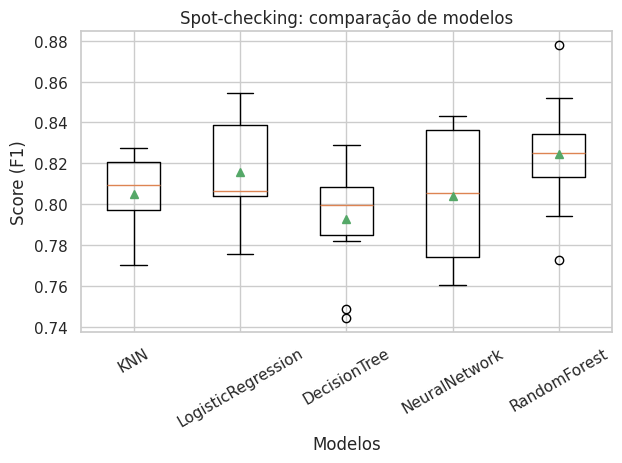

In [3]:
plt.figure()
plt.boxplot([results_raw[m] for m in results_raw.keys()], tick_labels=list(results_raw.keys()),showmeans=True)
plt.title("Spot-checking: comparação de modelos")
plt.xlabel("Modelos")
plt.ylabel("Score (F1)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [4]:
#converter resultados em dataframe para análise
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="mean", ascending=False)
print(results_df)

                        mean       std
RandomForest        0.824348  0.027705
LogisticRegression  0.815753  0.027038
KNN                 0.804905  0.019936
NeuralNetwork       0.804164  0.031349
DecisionTree        0.792640  0.026041


com base na média gerada pelos modelos, escolhemos RandomForest e LogisticRegression para a otimização de hiperparâmetros

In [6]:
#6) APLICANDO A OTIMIZAÇÃO DE HIPERPARÂMETROS

#grid de parametros para a floresta aleatória - mais valores? outros hiperparâmetros?
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2', None],
    'model__class_weight': ['balanced', None]
}

#pipeline para RandomForest
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier())
])

cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

# Inner CV (tuning)
inner_cv = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

# Outer CV (avaliação do modelo otimizado) 
outer_cv = cv

# testando hiperparâmetros
# dividir conjunto entregue pelo cross_validate em 3 folds, para cada combinação de hiperparâmetros do RandomForest testa 3x,
# usa os hiperparâmetros definidos em param_grid, estratégia de avaliação é o f1-score, com a melhor combinação encontrada, 
# retorna o modelo treinado
search_nested = GridSearchCV(
    pipeline,
    param_grid, 
    cv=inner_cv,
    scoring='f1',
    refit=True
)

# avaliando o modelo
# divide o X_train em 10 folds, para cada uma das 10 iterações, escolhe um fold para teste e 9 para treino, em cada iteração 
# envia esse conjunto de treino para o grid search e recebe o melhor modelo treinado, testa o modelo no fold de teste
# isso acontece 10x: no fim, temos 10 scores de performance e 10 modelos treinados com parâmetros possivelmente diferentes
nested_scores = cross_validate(
    search_nested,
    X_train,
    y_train,
    cv=outer_cv,
    scoring='f1',
    return_estimator=True,
    return_train_score=True,
    verbose=1,
)


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed: 19.0min finished


In [8]:
# pegando a média e o desvio padrão dos scores obtidos no nested cv
nested_mean = nested_scores['test_score'].mean()
nested_std = nested_scores['test_score'].std()

print(f"Nested CV - Mean: {nested_mean:.4f}, Std: {nested_std:.4f}")


Nested CV - Mean: 0.8237, Std: 0.0267


In [10]:
# pegando os melhores hiperparâmetros de cada um dos modelos retornados pelo nested cv
[x.best_params_ for x in nested_scores['estimator']]

[{'model__class_weight': None,
  'model__max_depth': None,
  'model__max_features': 'sqrt',
  'model__min_samples_split': 5,
  'model__n_estimators': 200},
 {'model__class_weight': 'balanced',
  'model__max_depth': None,
  'model__max_features': None,
  'model__min_samples_split': 10,
  'model__n_estimators': 200},
 {'model__class_weight': 'balanced',
  'model__max_depth': 10,
  'model__max_features': 'sqrt',
  'model__min_samples_split': 2,
  'model__n_estimators': 100},
 {'model__class_weight': None,
  'model__max_depth': None,
  'model__max_features': 'sqrt',
  'model__min_samples_split': 10,
  'model__n_estimators': 100},
 {'model__class_weight': None,
  'model__max_depth': None,
  'model__max_features': 'log2',
  'model__min_samples_split': 10,
  'model__n_estimators': 200},
 {'model__class_weight': 'balanced',
  'model__max_depth': 10,
  'model__max_features': 'log2',
  'model__min_samples_split': 2,
  'model__n_estimators': 100},
 {'model__class_weight': 'balanced',
  'model__ma

Melhores hiperparâmetros (os que mais aparecem):
class_weight: balanced
max_depth: None
min_samples_split: 10
n_estimators: 200
max_features: log2

In [11]:
# 7) CRIANDO E TREINANDO O MODELO FINAL UTILIZANDO OS HIPERPARÂMETROS ESCOLHIDOS

modelo_final = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight= 'balanced', 
        min_samples_split=10,
        max_features='log2',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

# treino do modelo final
modelo_final.fit(X_train, y_train)



,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


=== PERFORMANCE FINAL NO CONJUNTO DE TESTE ===
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       772
           1       0.91      0.76      0.83       773

    accuracy                           0.84      1545
   macro avg       0.85      0.84      0.84      1545
weighted avg       0.85      0.84      0.84      1545



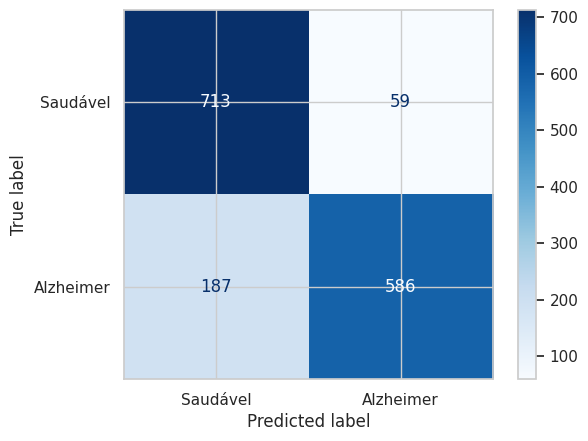

In [12]:
# 8) FAZENDO AS PREDIÇÕES USANDO O MODELO FINAL
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1] #probabilidade - criar tabela pra ver depois

#relatório de performance
print("=== PERFORMANCE FINAL NO CONJUNTO DE TESTE ===")
print(classification_report(y_test, y_pred))

# gerando matriz de confusão visual
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', display_labels=['Saudável', 'Alzheimer'])
plt.show()

In [ ]:
# 1. Criar o DataFrame de comparação
# Usamos .values para garantir que o Pandas não se perca com os índices
df_comparacao = pd.DataFrame({
    'Valor Real (Target)': y_test.values,
    'Predição do Modelo': y_pred,
    'Confiança (Probabilidade %)': (y_proba * 100).round(2)
})

# 2. Adicionar uma coluna para identificar se o modelo acertou ou errou (ajuda na visualização)
df_comparacao['Status'] = df_comparacao.apply(
    lambda x: '✅ Acertou' if x['Valor Real (Target)'] == x['Predição do Modelo'] else '❌ Errou', axis=1
)

# 3. Visualizar as primeiras 15 inserções
print("Amostra de Predições do NeuroPredict:")
display(df_comparacao.head(15))

Amostra de Predições do NeuroPredict:


,Valor Real (Target),Predição do Modelo,Confiança (Probabilidade %),Status
0,1,1,96.89,✅ Acertou
1,1,1,97.28,✅ Acertou
2,1,1,96.63,✅ Acertou
3,0,0,37.12,✅ Acertou
4,1,1,98.91,✅ Acertou
5,1,1,99.56,✅ Acertou
6,1,1,84.82,✅ Acertou
7,1,1,95.23,✅ Acertou
8,0,0,12.45,✅ Acertou
9,0,0,10.82,✅ Acertou


In [ ]:
# 1. Criar o DataFrame base com todos os resultados
df_comparacao = pd.DataFrame({
    'Valor Real': y_test.values,
    'Predição': y_pred,
    'Confiança (%)': (y_proba * 100).round(2)
})

# 2. Mapear os nomes para ficar mais fácil de ler (Opcional)
mapeamento = {0: 'Saudável', 1: 'Alzheimer'}
df_comparacao['Valor Real'] = df_comparacao['Valor Real'].map(mapeamento)
df_comparacao['Predição'] = df_comparacao['Predição'].map(mapeamento)

# 3. Filtrar apenas onde o Valor Real é diferente da Predição
# Isso isola apenas as falhas do modelo
df_erros = df_comparacao[df_comparacao['Valor Real'] != df_comparacao['Predição']]

# 4. Mostrar os 15 primeiros erros
print(f"Total de erros encontrados: {len(df_erros)}")
print("Amostra de 15 casos onde o modelo falhou:")
display(df_erros.head(15))

Total de erros encontrados: 246
Amostra de 15 casos onde o modelo falhou:


,Valor Real,Predição,Confiança (%)
17,Alzheimer,Saudável,40.21
35,Alzheimer,Saudável,4.12
36,Alzheimer,Saudável,27.84
43,Alzheimer,Saudável,18.10
44,Alzheimer,Saudável,23.55
45,Alzheimer,Saudável,31.12
62,Saudável,Alzheimer,59.14
63,Alzheimer,Saudável,28.35
64,Alzheimer,Saudável,19.70
74,Alzheimer,Saudável,11.45


In [18]:
print(y_pred.size)

1545


In [13]:
import joblib

# salva o modelo treinado em um arquivo físico
joblib.dump(modelo_final, 'modelo_final_neuropredict.pkl')
print("Arquivo 'modelo_final_neuropredict.pkl' gerado com sucesso!")

Arquivo 'modelo_final_neuropredict.pkl' gerado com sucesso!


- No modelo construído, o F1 Score está mais alto que a média dos F1 Scores gerada pelo NestedCV, o que indica que a otimização de hiperparâmetros ajudou.
- O recall está baixo, o que é ruim, pois não queremos que o modelo diga que uma pessoa doente está saudável.
- Focar em melhorar o recall
- Fatores influenciadores: threshold (modelo só diz que é doente se a probabilidade for acima de 50%), função de perda (modelo trata o erro de prever doente como saudável com o mesmo custo que o erro inverso)
- Estratégias para aprimorar: class weight (como hiperparâmetro, dizer ao algoritmo que errar a classe 1 custa muito mais caro), ajuste do threshold (no pós processamento), no GridSearchCV usar a métrica recall ao invés de f1, analisar a Curva PR (ver em que nível de probabilidade os seus 23 erros - falsos negativos - começam a aparecer)
- Modelos para adicionar no spot-checking: XGBoost ou LightGBM (no Boosting cada árvore tenta corrigir especificamente os erros (os doentes perdidos) da árvore anterior), Naïve Bayes (É um modelo probabilístico simples. Ele costuma ter um Recall altíssimo, embora a precisão seja mais baixa)
